# Use Case 1: Loan Approval Prediction

## Problem Statement

Build a classification model to predict whether a customer loan application will be approved or rejected.

### Target Variable
- Loan_Status

### Evaluation Metrics
- Accuracy
- Precision
- Recall
- F1 Score
- ROC-AUC

In [77]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [78]:
# import libraries
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report
)

In [79]:
data = pd.read_csv('/content/drive/MyDrive/Machine_Learning/datasets/preprocessed_hdfc_loan_data.csv')

In [80]:
data.head()

,Loan_ID,Bank,Customer_Name,Gender,Married,Dependents,Education,Employment_Status,Applicant_Income,Coapplicant_Income,...,Customer_Sentiment,Unnamed: 39,Religion,State,City,PIN_Code,Aadhaar_Synthetic,Phone_Number,Email,Occupation
0,0,0,31,1,0,2,0,1,56976,0,...,2,NaN,2,0,5,857743,6.939290e+11,9068671773,31,8
1,1,0,31,1,0,0,0,3,1856,0,...,0,NaN,2,5,15,863836,6.325430e+11,9990772625,31,2
2,2,0,1,0,1,0,0,1,64553,0,...,2,NaN,2,4,19,834796,1.658050e+11,9195085016,1,12
3,3,0,4,1,0,0,0,1,88450,0,...,0,NaN,2,1,27,438590,5.528183e+10,9179335548,4,11
4,4,0,11,1,1,3,0,2,9539,0,...,1,NaN,4,9,12,495224,1.557790e+11,9795137116,11,14


In [81]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 48 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   Loan_ID                      1000 non-null   int64  
 1   Bank                         1000 non-null   int64  
 2   Customer_Name                1000 non-null   int64  
 3   Gender                       1000 non-null   int64  
 4   Married                      1000 non-null   int64  
 5   Dependents                   1000 non-null   int64  
 6   Education                    1000 non-null   int64  
 7   Employment_Status            1000 non-null   int64  
 8   Applicant_Income             1000 non-null   int64  
 9   Coapplicant_Income           1000 non-null   int64  
 10  Loan_Amount                  1000 non-null   int64  
 11  Loan_Term_Months             1000 non-null   int64  
 12  Credit_History               1000 non-null   int64  
 13  Property_Area      

In [82]:
# define features and target
X = data[['Applicant_Income',
          'Coapplicant_Income',
          'Loan_Amount',
          'Credit_History',
          'CIBIL_Score',
          'Employment_Status',
          'Existing_EMIs',
          'Debt_to_Income_Ratio',
          'Education',
          'Property_Area']]

y = data['Loan_Status']

In [83]:
# train test split
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

# Training Models

# Model 1: Logistic Regression

Logistic Regression is a supervised classification algorithm used to predict categorical outcomes.

In this use case, Logistic Regression is used to predict whether a loan application will be approved or rejected.

In [84]:
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler

# Standardize the features
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Train model
lr_model = LogisticRegression(max_iter=1000)
lr_model.fit(X_train_scaled, y_train)

# Predict
y_pred_lr = lr_model.predict(X_test_scaled)


## Classification Report

The classification report provides Precision, Recall, F1 Score, and Support for each class.

In [85]:
# classification report

print("Classification Report for Logistic Regression :")
print(classification_report(y_test, y_pred_lr))

Classification Report for Logistic Regression :
              precision    recall  f1-score   support

           0       0.87      0.93      0.90       125
           1       0.86      0.76      0.81        75

    accuracy                           0.86       200
   macro avg       0.86      0.84      0.85       200
weighted avg       0.86      0.86      0.86       200



## Confusion Matrix

A confusion matrix summarizes the model predictions and actual values.

In [86]:
print("Confusion Matrix for Logistic Rgression: ")
cm_lr=confusion_matrix(y_test, y_pred_lr)
print(cm_lr)

Confusion Matrix for Logistic Rgression: 
[[116   9]
 [ 18  57]]


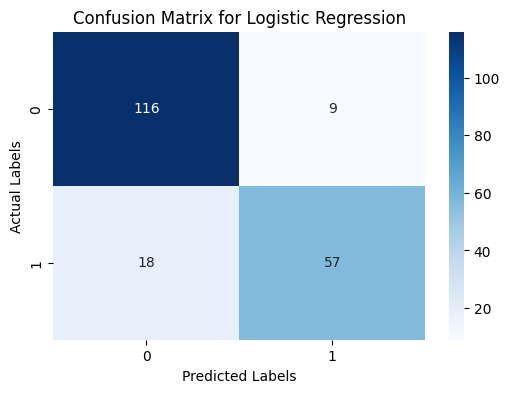

In [87]:
# Visualization

plt.figure(figsize =(6,4))

sns.heatmap(
    cm_lr,
    annot=True,
    fmt='d',
    cmap='Blues'
)

plt.title('Confusion Matrix for Logistic Regression')
plt.xlabel('Predicted Labels')
plt.ylabel('Actual Labels')

plt.show()

# Model 2: Decision Tree Classifier

Decision Trees classify observations by learning a sequence of decision rules from the training data.

In [88]:
from sklearn.tree import DecisionTreeClassifier

dt_model = DecisionTreeClassifier(
    max_depth=4,
    min_samples_split =2,
    min_samples_leaf =1,
    random_state =42)

dt_model.fit(X_train, y_train)

DecisionTreeClassifier(max_depth=4, random_state=42)

In [89]:
# predict

y_pred_dt = dt_model.predict(X_test)

In [90]:
# Evaluation Metrics

#classification report

print("Classification Report for Decision Tree :")
print(classification_report(y_test, y_pred_dt))

Classification Report for Decision Tree :
              precision    recall  f1-score   support

           0       0.85      0.89      0.87       125
           1       0.80      0.73      0.76        75

    accuracy                           0.83       200
   macro avg       0.82      0.81      0.82       200
weighted avg       0.83      0.83      0.83       200



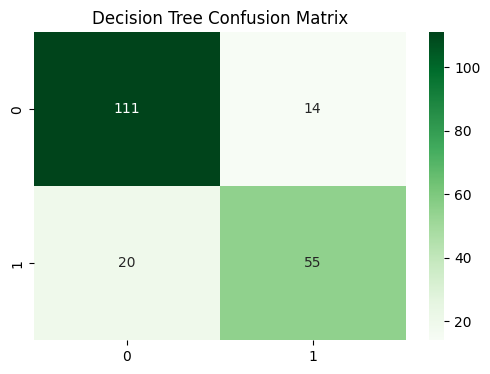

In [91]:
# confusion matrix
cm_dt = confusion_matrix(y_test, y_pred_dt)

plt.figure(figsize=(6,4))

sns.heatmap(
    cm_dt,
    annot=True,
    fmt='d',
    cmap='Greens'
)

plt.title("Decision Tree Confusion Matrix")

plt.show()

In [92]:
print(f"Accuracy of Decision Tree: {dt_model.score(X_test,y_test): .4f}")

print(f'Feature Importance :{dt_model.feature_importances_}')

Accuracy of Decision Tree:  0.8300
Feature Importance :[0.         0.         0.18588797 0.10572846 0.00813664 0.
 0.00214343 0.69810349 0.         0.        ]


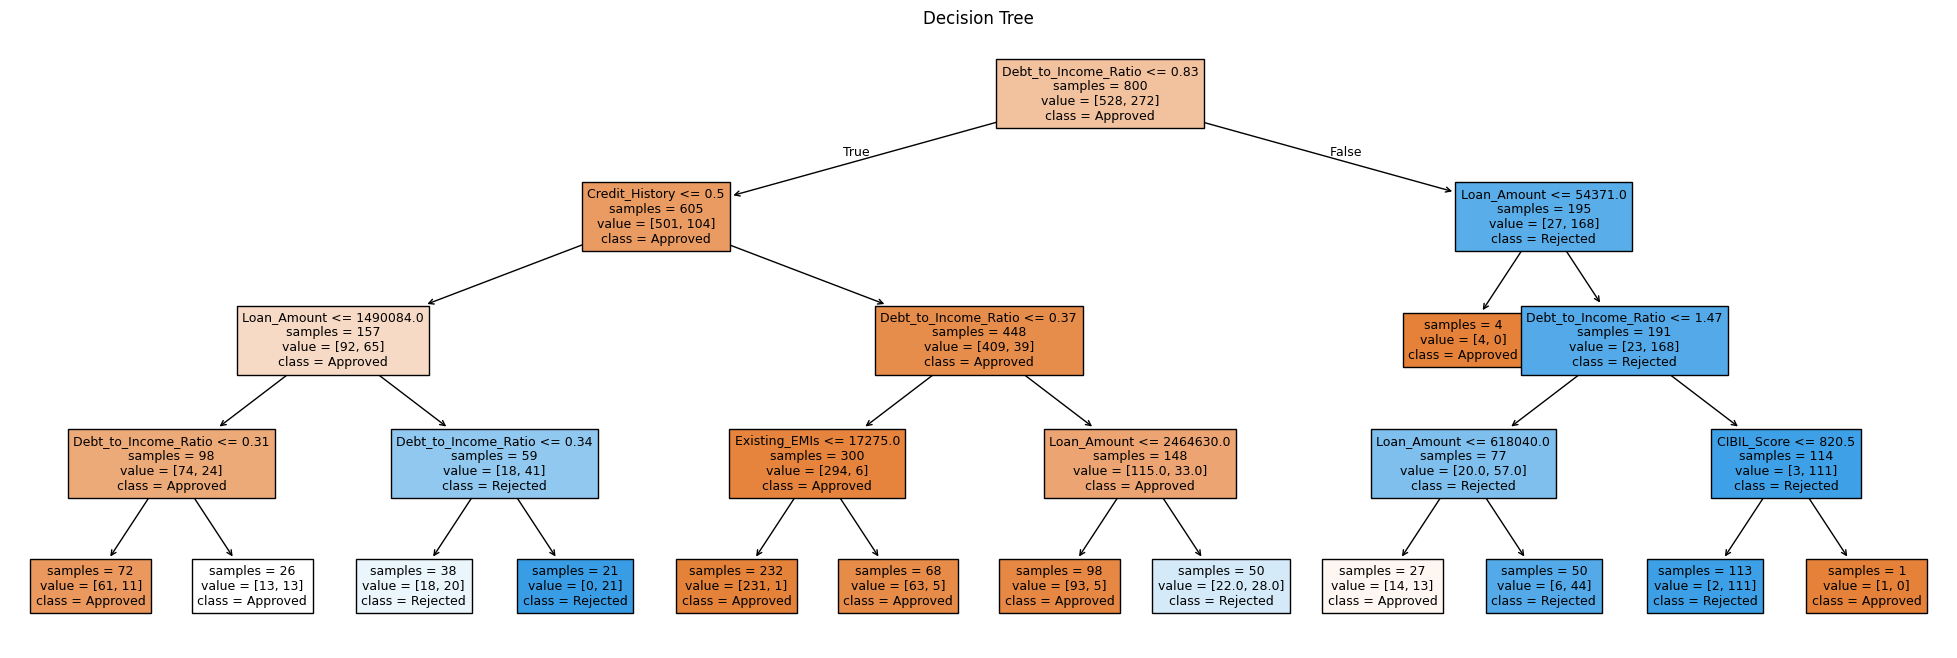

In [93]:
# visulaize tree

from sklearn.tree import plot_tree
plt.figure(figsize=(25,8))
plot_tree(dt_model, filled=True, feature_names=X.columns, class_names=['Approved','Rejected'], fontsize=9, max_depth=4,impurity=False, precision=2)
plt.title("Decision Tree")
plt.show()

# Model 3: Random Forest Classifier

Random Forest combines multiple decision trees to improve prediction accuracy and reduce overfitting.

In [94]:
from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier(
    random_state=42
)

rf_model.fit(X_train, y_train)

y_pred_rf = rf_model.predict(X_test
)

In [95]:
# Evaluation Metrics

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
)

print("Accuracy: ",accuracy_score(y_test, y_pred_rf))
print("Precision: ",precision_score(y_test, y_pred_rf))
print("Recall: ",recall_score(y_test, y_pred_rf))
print("F1 Score: ",f1_score(y_test, y_pred_rf))


Accuracy:  0.88
Precision:  0.8923076923076924
Recall:  0.7733333333333333
F1 Score:  0.8285714285714286


<Axes: >

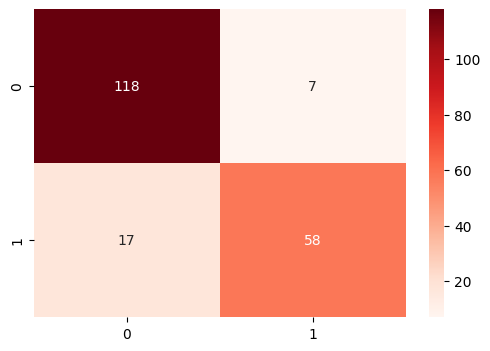

In [96]:
# confusion matrix

cm_rf = confusion_matrix(y_test, y_pred_rf)

plt.figure(figsize=(6,4))

sns.heatmap(
    cm_rf,
    annot=True,
    fmt='d',
    cmap='Reds'
)

# Hyperparameter Tuning

Hyperparameter tuning is performed using GridSearchCV to identify the optimal parameter combination for the Logistic Regression model.

In [97]:
from sklearn.model_selection import GridSearchCV

# parameter grid

params = {
    'n_estimators': [50, 100, 200],
    'max_depth': [None, 10, 20, 30],
    'min_samples_split': [2,5]
}



In [98]:
# Grid search
grid = GridSearchCV(
    RandomForestClassifier(),
    params,
    cv=5,
    scoring='f1'
)

grid.fit(X_train, y_train)

GridSearchCV(cv=5, estimator=RandomForestClassifier(),
             param_grid={'max_depth': [None, 10, 20, 30],
                         'min_samples_split': [2, 5],
                         'n_estimators': [50, 100, 200]},
             scoring='f1')

In [99]:
print("Best Parameters:")
print(grid.best_params_)

Best Parameters:
{'max_depth': 10, 'min_samples_split': 2, 'n_estimators': 50}


In [100]:
# best estimator

best_rf = grid.best_estimator_

best_pred = best_rf.predict(X_test)

In [101]:
print(
    classification_report(
        y_test,
        best_pred
    )
)

              precision    recall  f1-score   support

           0       0.87      0.94      0.90       125
           1       0.89      0.76      0.82        75

    accuracy                           0.88       200
   macro avg       0.88      0.85      0.86       200
weighted avg       0.88      0.88      0.87       200



# Feature Importance Analysis

The feature importance values obtained from the Tuned Random Forest model are used to identify the features that have the greatest impact on loan approval prediction.

In [102]:
importance = best_rf.feature_importances_

feature_importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': importance
})

feature_importance.sort_values(
    by='Importance',
    ascending=False
)

,Feature,Importance
7,Debt_to_Income_Ratio,0.361300
0,Applicant_Income,0.145897
2,Loan_Amount,0.131156
6,Existing_EMIs,0.111349
4,CIBIL_Score,0.108379
3,Credit_History,0.050887
1,Coapplicant_Income,0.037645
5,Employment_Status,0.027554
9,Property_Area,0.016888
8,Education,0.008945


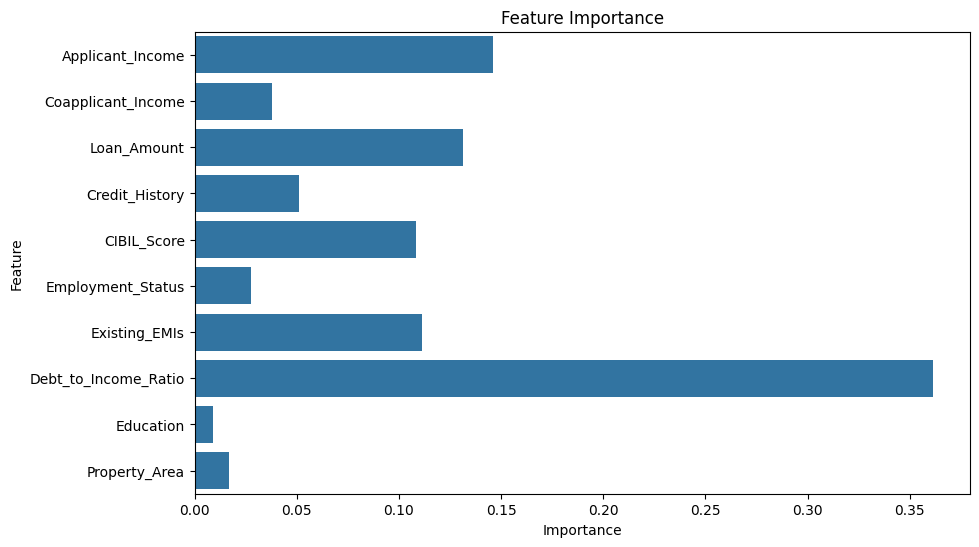

In [103]:
# visualization for feature Importance

plt.figure(figsize=(10,6))

sns.barplot(
    x='Importance',
    y='Feature',
    data=feature_importance

)
plt.title("Feature Importance")
plt.show()

# Final Model Summary

Three classification algorithms were trained and evaluated:

1. Logistic Regression
2. Decision Tree
3. Random Forest

The models were compared using Accuracy, Precision, Recall, F1-Score, and overall classification performance.

Among the three models, Random Forest achieved the best results with the highest accuracy and F1-score. Therefore, Random Forest was selected as the final model for loan approval prediction.

Hyperparameter tuning was performed using GridSearchCV to further optimize the model and improve its predictive performance.

In [104]:
#Create Model Comparison Table
acc_lr = accuracy_score(y_test, y_pred_lr)
precision_lr = precision_score(y_test, y_pred_lr)
recall_lr = recall_score(y_test, y_pred_lr)
f1_lr = f1_score(y_test, y_pred_lr)

acc_dt = accuracy_score(y_test, y_pred_dt)
precision_dt = precision_score(y_test, y_pred_dt)
recall_dt = recall_score(y_test, y_pred_dt)
f1_dt = f1_score(y_test, y_pred_dt)

acc_rf = accuracy_score(y_test, y_pred_rf)
precision_rf = precision_score(y_test, y_pred_rf)
recall_rf = recall_score(y_test, y_pred_rf)
f1_rf = f1_score(y_test, y_pred_rf)

acc_best = accuracy_score(y_test, best_pred)
precision_best = precision_score(y_test, best_pred)
recall_best = recall_score(y_test, best_pred)
f1_best = f1_score(y_test, best_pred)

results = pd.DataFrame({

'Model':[
    'Logistic Regression',
    'Decision Tree',
    'Random Forest',
    'Tuned Random Forest'
],

'Accuracy':[
    acc_lr,
    acc_dt,
    acc_rf,
    acc_best
],

'Precision':[
    precision_lr,
    precision_dt,
    precision_rf,
    precision_best
],

'Recall':[
    recall_lr,
    recall_dt,
    recall_rf,
    recall_best
],

'F1 Score':[
    f1_lr,
    f1_dt,
    f1_rf,
    f1_best
]

})

results

,Model,Accuracy,Precision,Recall,F1 Score
0,Logistic Regression,0.865,0.863636,0.760000,0.808511
1,Decision Tree,0.830,0.797101,0.733333,0.763889
2,Random Forest,0.880,0.892308,0.773333,0.828571
3,Tuned Random Forest,0.875,0.890625,0.760000,0.820144


In [105]:
import os

os.makedirs(
    "/content/drive/MyDrive/Machine_Learning/models",
    exist_ok=True
)

In [106]:
import joblib

joblib.dump(
    best_rf,
    "/content/drive/MyDrive/Machine_Learning/models/loan_approval_model.pkl"
)

['/content/drive/MyDrive/Machine_Learning/models/loan_approval_model.pkl']

In [107]:
#Verify Saved Model
loaded_rf = joblib.load("/content/drive/MyDrive/Machine_Learning/models/loan_approval_model.pkl")
loaded_rf.predict(
    X_test.head()
)

array([1, 0, 0, 0, 0])

In [108]:

# predicition pipeline

def predict_loan_approval(
    applicant_income,
    coapplicant_income,
    loan_amount,
    credit_history,
    cibil_score,
    employment_status,
    existing_emis,
    debt_to_income_ratio,
    education,
    property_area):
  data = pd.DataFrame({
      'Applicant_Income': [applicant_income],
      'Coapplicant_Income': [coapplicant_income],
      'Loan_Amount': [loan_amount],
      'Credit_History': [credit_history],
      'CIBIL_Score': [cibil_score],
      'Employment_Status': [employment_status],
      'Existing_EMIs': [existing_emis],
      'Debt_to_Income_Ratio': [debt_to_income_ratio],
      'Education': [education],
      'Property_Area': [property_area]
  })

  prediction = loaded_rf.predict(data)
  return prediction[0]


In [109]:
# test pipeline

loaded_model = loaded_rf

predict_loan_approval(
    applicant_income=20000,
    coapplicant_income=10000,
    loan_amount=10000,
    credit_history=1,
    cibil_score=780,
    employment_status=2,
    existing_emis=18373,
    debt_to_income_ratio=1.557,
    education=1,
    property_area=2

)

np.int64(0)

# Project Conclusion

In this notebook, a loan approval prediction system was developed using machine learning classification techniques. The dataset was explored and preprocessed by handling categorical features and preparing the input variables for model training.

Three classification algorithms—Logistic Regression, Decision Tree, and Random Forest—were implemented and evaluated using Accuracy, Precision, Recall, and F1-Score. Hyperparameter tuning was performed using GridSearchCV to improve model performance.

Based on the comparative analysis, Random Forest achieved the best overall performance and was selected as the final model for loan approval prediction. Feature importance analysis was also performed to understand the factors influencing loan approval decisions.

## Learning Outcomes

Through this task, I learned:

- How to perform data preprocessing for a machine learning dataset.
- How to train and compare multiple classification algorithms.
- How to evaluate models using Accuracy, Precision, Recall, and F1-Score.
- How to apply GridSearchCV for hyperparameter tuning.
- How to interpret feature importance in Random Forest.
- How to save trained models and create a prediction pipeline for new data.

Overall, this task provided hands-on experience in building an end-to-end machine learning classification project and understanding the complete workflow involved in model development and evaluation.